In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
DATA_PATH = Path('/kaggle/input/datasets/shanegerami/ai-vs-human-text/AI_Human.csv')

df = pd.read_csv(DATA_PATH)

print(f'Loaded {len(df):,} rows from {DATA_PATH}')

Loaded 487,235 rows from /kaggle/input/datasets/shanegerami/ai-vs-human-text/AI_Human.csv


In [4]:
df.head()

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB


In [6]:
df.isna().sum()

text         0
generated    0
dtype: int64

In [7]:
label_counts = df['generated'].value_counts().sort_index()

print(f'Total texts: {len(df):,}')
print(f'Human-written texts: {label_counts.get(0, 0):,}')
print(f'AI-generated texts: {label_counts.get(1, 0):,}')

Total texts: 487,235
Human-written texts: 305,797
AI-generated texts: 181,438


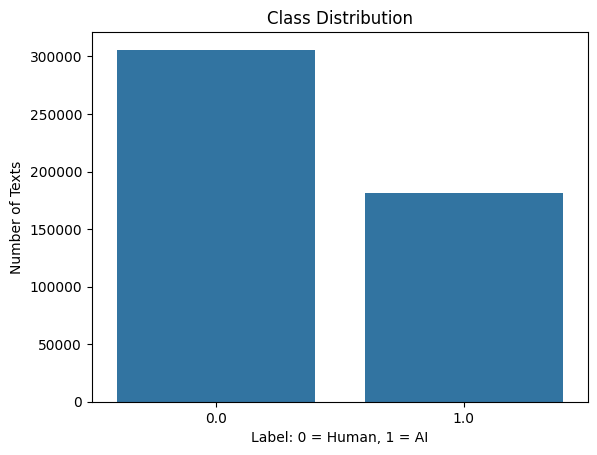

In [8]:
sns.countplot(data=df, x='generated')
plt.title('Class Distribution')
plt.xlabel('Label: 0 = Human, 1 = AI')
plt.ylabel('Number of Texts')
plt.show()

In [9]:
print(df.loc[0, 'text'][:500])

Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.

In like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle


In [10]:
df['generated'] = df['generated'].astype(int)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       487235 non-null  object
 1   generated  487235 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 7.4+ MB


In [12]:
X = df['text']
y = df['generated']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples: {len(X_test):,}')

Training samples: 389,788
Test samples: 97,447


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline


model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,             
        strip_accents='unicode',   
        stop_words='english',       
        token_pattern=r'(?u)\b[a-zA-Z]+\b',  
        max_features=50_000,
    )),
    ('classifier', MultinomialNB()),
])

model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, stop_words='english',
                                 strip_accents='unicode',
                                 token_pattern='(?u)\\b[a-zA-Z]+\\b')),
                ('classifier', MultinomialNB())])

In [16]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, stop_words='english',
                                 strip_accents='unicode',
                                 token_pattern='(?u)\\b[a-zA-Z]+\\b')),
                ('classifier', MultinomialNB())])

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}\n')
print(classification_report(
    y_test,
    y_pred,
    target_names=['Human', 'AI'],
    zero_division=0,
))

Accuracy: 0.955

              precision    recall  f1-score   support

       Human       0.95      0.98      0.96     61159
          AI       0.96      0.92      0.94     36288

    accuracy                           0.96     97447
   macro avg       0.96      0.95      0.95     97447
weighted avg       0.96      0.96      0.96     97447



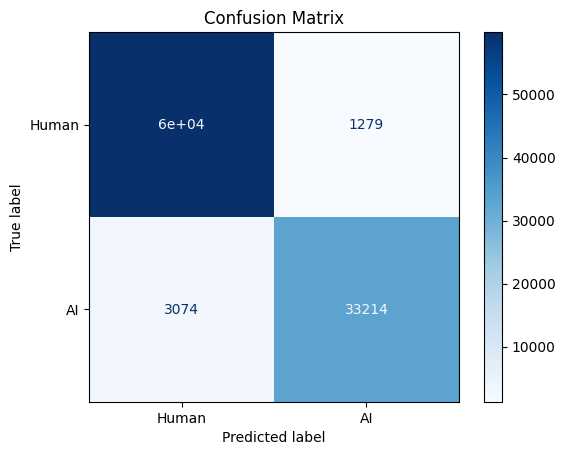

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Human', 'AI'],
    cmap='Blues',
)
plt.title('Confusion Matrix')
plt.show()
     

In [20]:
#Testing with Human-written

example_text = 'Here’s why. I’m fully aware that most of what I read online these days is at the very least AI-assisted, if not entirely written by AI. Generally, I don’t mind. My main concern is whether what I’m reading is accurate or not. If I want to know how to operate my toaster, I don’t need to be assured that a human wrote the instructions. But when it comes to art and journalism, come on! With poetry, prose, etc., the whole point is the masterful placing of words in sentences, in paragraphs for the enjoyment and stirring of the reader.'
prediction = model.predict([example_text])[0]
probabilities = model.predict_proba([example_text])[0]

label = 'AI-generated' if prediction == 1 else 'Human-written'
confidence = probabilities[prediction]
print(f'Prediction: {label}')
print(f'Model confidence: {confidence:.2%}')

Prediction: Human-written
Model confidence: 78.68%


In [21]:
#Testing with AI-generated

example_text = 'Achieving 100% human-written essays on Medium relies on sharing raw personal experiences, specific real-life details, and an imperfect conversational voice rather than relying on generic AI templates or sterile corporate structures.'
prediction = model.predict([example_text])[0]
probabilities = model.predict_proba([example_text])[0]

label = 'AI-generated' if prediction == 1 else 'Human-written'
confidence = probabilities[prediction]
print(f'Prediction: {label}')
print(f'Model confidence: {confidence:.2%}')

Prediction: AI-generated
Model confidence: 96.97%


In [42]:
MODEL_DIR = Path('/kaggle/working/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / 'model.joblib'

joblib.dump(model, MODEL_PATH)

print(f'Model saved to: {MODEL_PATH.resolve()}')

Model saved to: /kaggle/working/models/model.joblib


In [43]:
loaded_model = joblib.load(MODEL_PATH)
loaded_model.predict(['This is a quick test after loading the model.'])

array([0])